In [1]:
%pip install -q tqdm
%matplotlib inline

import sys
import pickle
import os
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import datasets, transforms as T

# Relative paths (run this script from student_start_pack/)
# Using absolute paths to avoid issues with different working directories
if "__file__" in globals():
    FILE_DIR = Path(__file__).resolve().parent
else:
    # Jupyter notebooks do not have __file__; assume we are in the notebook's directory
    FILE_DIR = Path.cwd()

PROJECT_ROOT = FILE_DIR.parent
SCRIPTS_DIR = PROJECT_ROOT / 'scripts'
KAGGLE_ROOT = PROJECT_ROOT / 'ArtBench-10'

if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

from artbench_local_dataset import load_kaggle_artbench10_splits

class HFDatasetTorch(Dataset):
    def __init__(self, hf_split, transform=None, indices=None):
        self.ds = hf_split
        self.transform = transform
        self.indices = list(range(len(hf_split))) if indices is None else list(indices)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        ex = self.ds[real_idx]
        img = ex["image"]
        y = int(ex["label"])
        x = self.transform(img) if self.transform else img
        return x, y


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


reproducibility and device selection

In [2]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def get_device():
    if torch.cuda.is_available():
        return torch.device('cuda')
    if torch.backends.mps.is_available() and torch.backends.mps.is_built():
        return torch.device('mps')
    return torch.device('cpu')


set_seed(42)
device = get_device()
print('Device:', device)

Device: cuda


In [3]:
def build_loaders(
    dataset_name='mnist',
    batch_size=128,
    train_limit=30000,
    test_limit=5000,
    data_root='data',
    num_workers=0,
):
    dataset_name = dataset_name.lower()

    if dataset_name == 'mnist':
        channels = 1
        image_size = 32
        transform = T.Compose([
            T.Resize((32, 32)),
            T.ToTensor(),
            T.Normalize((0.5,), (0.5,)),
        ])
        train_ds = datasets.MNIST(data_root, train=True, download=True, transform=transform)
        test_ds = datasets.MNIST(data_root, train=False, download=True, transform=transform)
        class_names = [str(i) for i in range(10)]
    elif dataset_name in ('cifar', 'cifar10'):
        channels = 3
        image_size = 32
        transform = T.Compose([
            T.ToTensor(),
            T.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
        ])
        train_ds = datasets.CIFAR10(data_root, train=True, download=True, transform=transform)
        test_ds = datasets.CIFAR10(data_root, train=False, download=True, transform=transform)
        class_names = train_ds.classes
    elif dataset_name == 'artbench':
        channels = 3
        image_size = 32
        transform = T.Compose([
            T.Resize(image_size),
            T.CenterCrop(image_size),
            T.ToTensor(),
            T.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
        ])
        
        hf_ds = load_kaggle_artbench10_splits(KAGGLE_ROOT)
        train_ds = HFDatasetTorch(hf_ds["train"], transform=transform)
        test_ds = HFDatasetTorch(hf_ds["test"], transform=transform)
        class_names = hf_ds["train"].features["label"].names
    else:
        raise ValueError("dataset_name must be 'mnist', 'cifar10' or 'artbench'.")

    if train_limit is not None:
        train_ds = Subset(train_ds, list(range(min(train_limit, len(train_ds)))))
    if test_limit is not None:
        test_ds = Subset(test_ds, list(range(min(test_limit, len(test_ds)))))

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers)
    return train_loader, test_loader, channels, image_size, class_names

In [4]:
def denorm(x):
    return (x + 1.0) / 2.0


def show_image_grid(images, channels, title='Images', n_show=25):
    images = images[:n_show].detach().cpu()
    images = denorm(images).clamp(0, 1)

    n = images.size(0)
    grid = int(np.ceil(np.sqrt(n)))
    fig, axes = plt.subplots(grid, grid, figsize=(grid * 1.6, grid * 1.6))
    axes = np.atleast_2d(axes)

    idx = 0
    for i in range(grid):
        for j in range(grid):
            ax = axes[i, j]
            ax.axis('off')
            if idx < n:
                if channels == 1:
                    ax.imshow(images[idx, 0], cmap='gray', vmin=0, vmax=1)
                else:
                    ax.imshow(images[idx].permute(1, 2, 0))
            idx += 1

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

In [5]:
class DCGenerator(nn.Module):
    def __init__(self, latent_dim=100, image_channels=3, ngf=64):
        super().__init__()
        self.latent_dim = latent_dim
        self.net = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, ngf * 4, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),
            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),
            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),
            nn.ConvTranspose2d(ngf, image_channels, 4, 2, 1, bias=False),
            nn.Tanh(),
        )

    def forward(self, z):
        z = z.view(z.size(0), self.latent_dim, 1, 1)
        return self.net(z)


class DCDiscriminator(nn.Module):
    def __init__(self, image_channels=3, ndf=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(image_channels, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf * 4, 1, 4, 1, 0, bias=False),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.net(x).view(-1, 1)


def init_dcgan_weights(m):
    classname = m.__class__.__name__
    if 'Conv' in classname:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif 'BatchNorm' in classname:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

def plot_gan_losses(history, title='GAN losses'):
    plt.figure(figsize=(7, 4))
    plt.plot(history['d_loss'], label='Discriminator loss')
    plt.plot(history['g_loss'], label='Generator loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


def save_checkpoint(generator, discriminator, history, checkpoint_path, latent_dim, channels, image_size):
    checkpoint_path = Path(checkpoint_path)
    checkpoint_path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(
        {
            'generator': generator.state_dict(),
            'discriminator': discriminator.state_dict(),
            'history': history,
            'config': {
                'latent_dim': latent_dim,
                'channels': channels,
                'image_size': image_size,
            },
        },
        checkpoint_path,
    )
    print('Saved checkpoint to', checkpoint_path)


@torch.no_grad()
def load_dcgan_generator_for_inference(checkpoint_path):
    ckpt = torch.load(checkpoint_path, map_location=device)
    cfg = ckpt['config']
    generator = DCGenerator(latent_dim=cfg['latent_dim'], image_channels=cfg['channels']).to(device)
    generator.load_state_dict(ckpt['generator'])
    generator.eval()
    return generator, cfg, ckpt.get('history', None)



In [6]:
def train_gan(generator, discriminator, loader, latent_dim, epochs=20, lr=2e-4):
    criterion = nn.BCELoss()
    opt_g = torch.optim.Adam(generator.parameters(), lr=lr, betas=(0.5, 0.999))
    opt_d = torch.optim.Adam(discriminator.parameters(), lr=lr, betas=(0.5, 0.999))

    history = {'g_loss': [], 'd_loss': []}
    generator.train()
    discriminator.train()

    for epoch in range(epochs):
        g_running = 0.0
        d_running = 0.0
        n_batches = 0

        for real, _ in tqdm(loader, desc=f'Epoch {epoch + 1}/{epochs}', leave=False):
            real = real.to(device)
            bs = real.size(0)

            real_targets = torch.ones(bs, 1, device=device)
            fake_targets = torch.zeros(bs, 1, device=device)

            # TODO START - Discriminator update
            # 1) Reset discriminator gradients for the new mini-batch.
            opt_d.zero_grad()
            # 2) Measure how well it recognizes real images as real.
            discriminator_real_outputs = discriminator(real)
            d_loss_real = criterion(discriminator_real_outputs, real_targets)
            # 3) Sample latent noise and generate a fake batch.
            noise = torch.randn(bs, latent_dim, device=device)
            fake = generator(noise)
            # 4) Measure how well it recognizes fake images as fake.
            discriminator_fake_outputs = discriminator(fake.detach())
            d_loss_fake = criterion(discriminator_fake_outputs, fake_targets)
            # 5) Combine both real/fake discriminator losses.
            d_loss = d_loss_real + d_loss_fake
            # 6) Backpropagate discriminator loss and update discriminator weights.
            d_loss.backward()
            opt_d.step()
            # TODO END

            if d_loss is None:
                raise NotImplementedError('Implement Discriminator update in train_gan.')

            # --- TODO START - Generator update ---
            # 1) Reset generator gradients for the new mini-batch.
            opt_g.zero_grad() # Dica: use o otimizador opt_g em vez de generator.zero_grad() para garantir
            
            # 2) Sample fresh latent noise and generate a fake batch.
            noise = torch.randn(bs, latent_dim, device=device)
            fake = generator(noise)
            
            # 3) Evaluate how convincing those fake images look to the discriminator.
            # Passamos as imagens FALSAS pelo DISCRIMINADOR (sem detach!)
            discriminator_outputs_on_fake = discriminator(fake)
            
            # 4) Compute generator loss so fake images are pushed toward "real" predictions.
            # O Gerador quer que o Discriminador diga "1" (real_targets) para suas imagens falsas
            g_loss = criterion(discriminator_outputs_on_fake, real_targets)
            
            # 5) Backpropagate generator loss and update generator weights.
            g_loss.backward()
            opt_g.step() # Atualiza os pesos do Gerador usando seu próprio otimizador
            # TODO END

            if g_loss is None:
                raise NotImplementedError('Implement Generator update in train_gan.')

            # TODO START - Bookkeeping
            g_running += g_loss.item()
            d_running += d_loss.item()
            n_batches += 1
            # TODO END

        history['g_loss'].append(g_running / max(n_batches, 1))
        history['d_loss'].append(d_running / max(n_batches, 1))

        print(
            f"Epoch {epoch + 1:02d}/{epochs} | "
            f"D loss: {history['d_loss'][-1]:.4f} | "
            f"G loss: {history['g_loss'][-1]:.4f}"
        )

    return history

Dataset source: kaggle root='c:\Users\ricar\OneDrive\Desktop\Curso\IAG\Projeto\artbench\ArtBench-10'


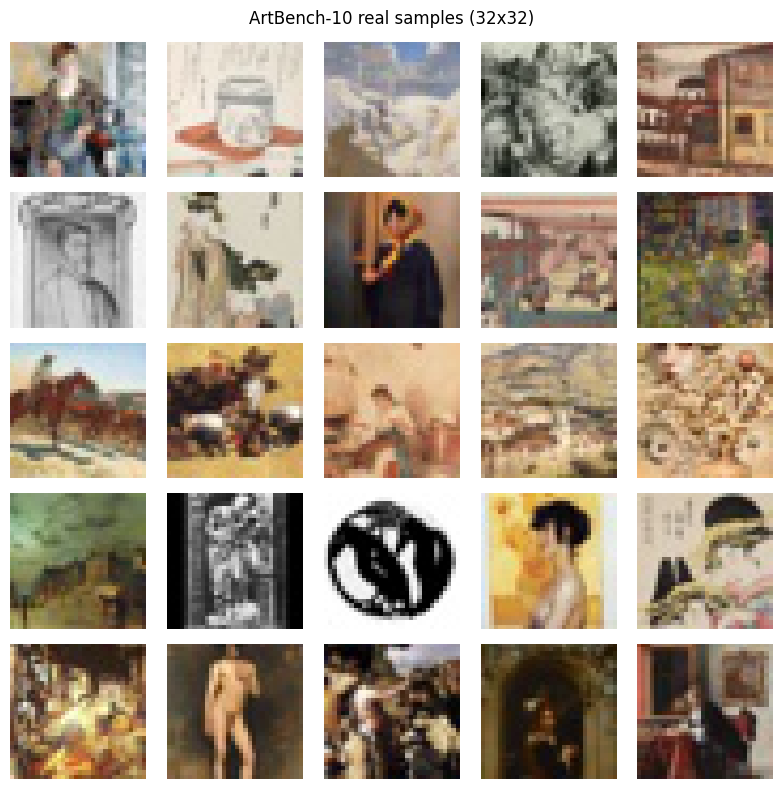

In [7]:
artbench_train_loader, artbench_test_loader, artbench_channels, artbench_image_size, artbench_classes = build_loaders(
    dataset_name='artbench',
    batch_size=128,
    train_limit=10000, # 20% of the training data for development
    test_limit=5000,
    data_root='IAGdata/artbench-10-python',
)

x_artbench, _ = next(iter(artbench_train_loader))
show_image_grid(x_artbench, channels=artbench_channels, title='ArtBench-10 real samples (32x32)', n_show=25)

In [11]:
# TODO START
artbench_latent_dim = 100
artbench_epochs = 50 # Increased epochs for better results on ArtBench
artbench_lr = 2e-4
artbench_ckpt = Path('runs/dcgan/artbench_dcgan.pt')

artbench_generator = DCGenerator(latent_dim=artbench_latent_dim, image_channels=artbench_channels).to(device)
artbench_discriminator = DCDiscriminator(image_channels=artbench_channels).to(device)
# TODO END

if artbench_generator is None or artbench_discriminator is None:
    raise NotImplementedError('Instantiate ArtBench DCGAN models inside TODO block.')

# TODO START
# Recommended: initialize DCGAN weights
artbench_generator.apply(init_dcgan_weights)
artbench_discriminator.apply(init_dcgan_weights)
# TODO END

artbench_history = train_gan(
    generator=artbench_generator,
    discriminator=artbench_discriminator,
    loader=artbench_train_loader,
    latent_dim=artbench_latent_dim,
    epochs=artbench_epochs,
    lr=artbench_lr,
)

plot_gan_losses(artbench_history, title='ArtBench-10 DCGAN losses')

save_checkpoint(
    generator=artbench_generator,
    discriminator=artbench_discriminator,
    history=artbench_history,
    checkpoint_path=artbench_ckpt,
    latent_dim=artbench_latent_dim,
    channels=artbench_channels,
    image_size=artbench_image_size,
)

Epoch 1/50:   0%|          | 0/79 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [12]:
@torch.no_grad()
def run_inference(generator, latent_dim, channels, n_samples=25, seed=123, title='Generator inference'):
    # TODO START
    # 1) set torch seed para garantir que os resultados possam ser reproduzidos
    torch.manual_seed(seed)
    
    # 2) sample z: Criamos o ruído aleatório. O formato é [Quantidade_de_imagens, Tamanho_do_vetor_latente]
    z = torch.randn(n_samples, latent_dim, device=device)
    
    # 3) generate fake images: Passamos o ruído pelo Gerador para obter as imagens
    fake = generator(z)
    # TODO END

    if z is None or fake is None:
        raise NotImplementedError('Implement run_inference for DCGAN.')

    show_image_grid(fake, channels=channels, title=title, n_show=n_samples)


@torch.no_grad()
def latent_walk(generator, latent_dim, channels, steps=10, title='Latent interpolation'):
    # TODO START
    # 1) sample z0 and z1: Sorteamos os nossos pontos de "partida" e "chegada" no espaço latente
    z0 = torch.randn(1, latent_dim, device=device)
    z1 = torch.randn(1, latent_dim, device=device)
    
    # 2) interpolate with alpha in [0, 1]
    # linspace cria um tensor com 'steps' valores, espaçados igualmente entre 0 e 1
    alphas = torch.linspace(0, 1, steps, device=device)
    
    # Fazemos a interpolação linear para cada alpha e usamos torch.cat para empilhar tudo
    # em um único tensor 'z' com a forma [steps, latent_dim]
    z = torch.cat([(1 - a) * z0 + a * z1 for a in alphas], dim=0)
    
    # 3) generate fake images: Transformamos essa "caminhada" em imagens visuais
    fake = generator(z)
    # TODO END

    if z is None or fake is None:
        raise NotImplementedError('Implement latent_walk for DCGAN.')

    show_image_grid(fake, channels=channels, title=title, n_show=steps)

Gerando amostras aleatórias do espaço latente...


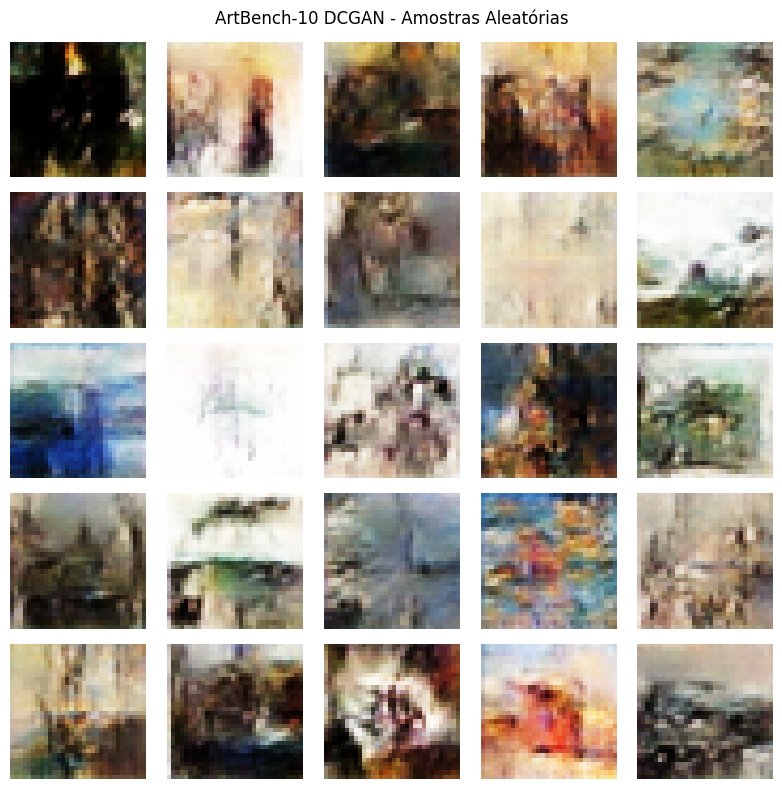


Caminhando suavemente pelo espaço latente...


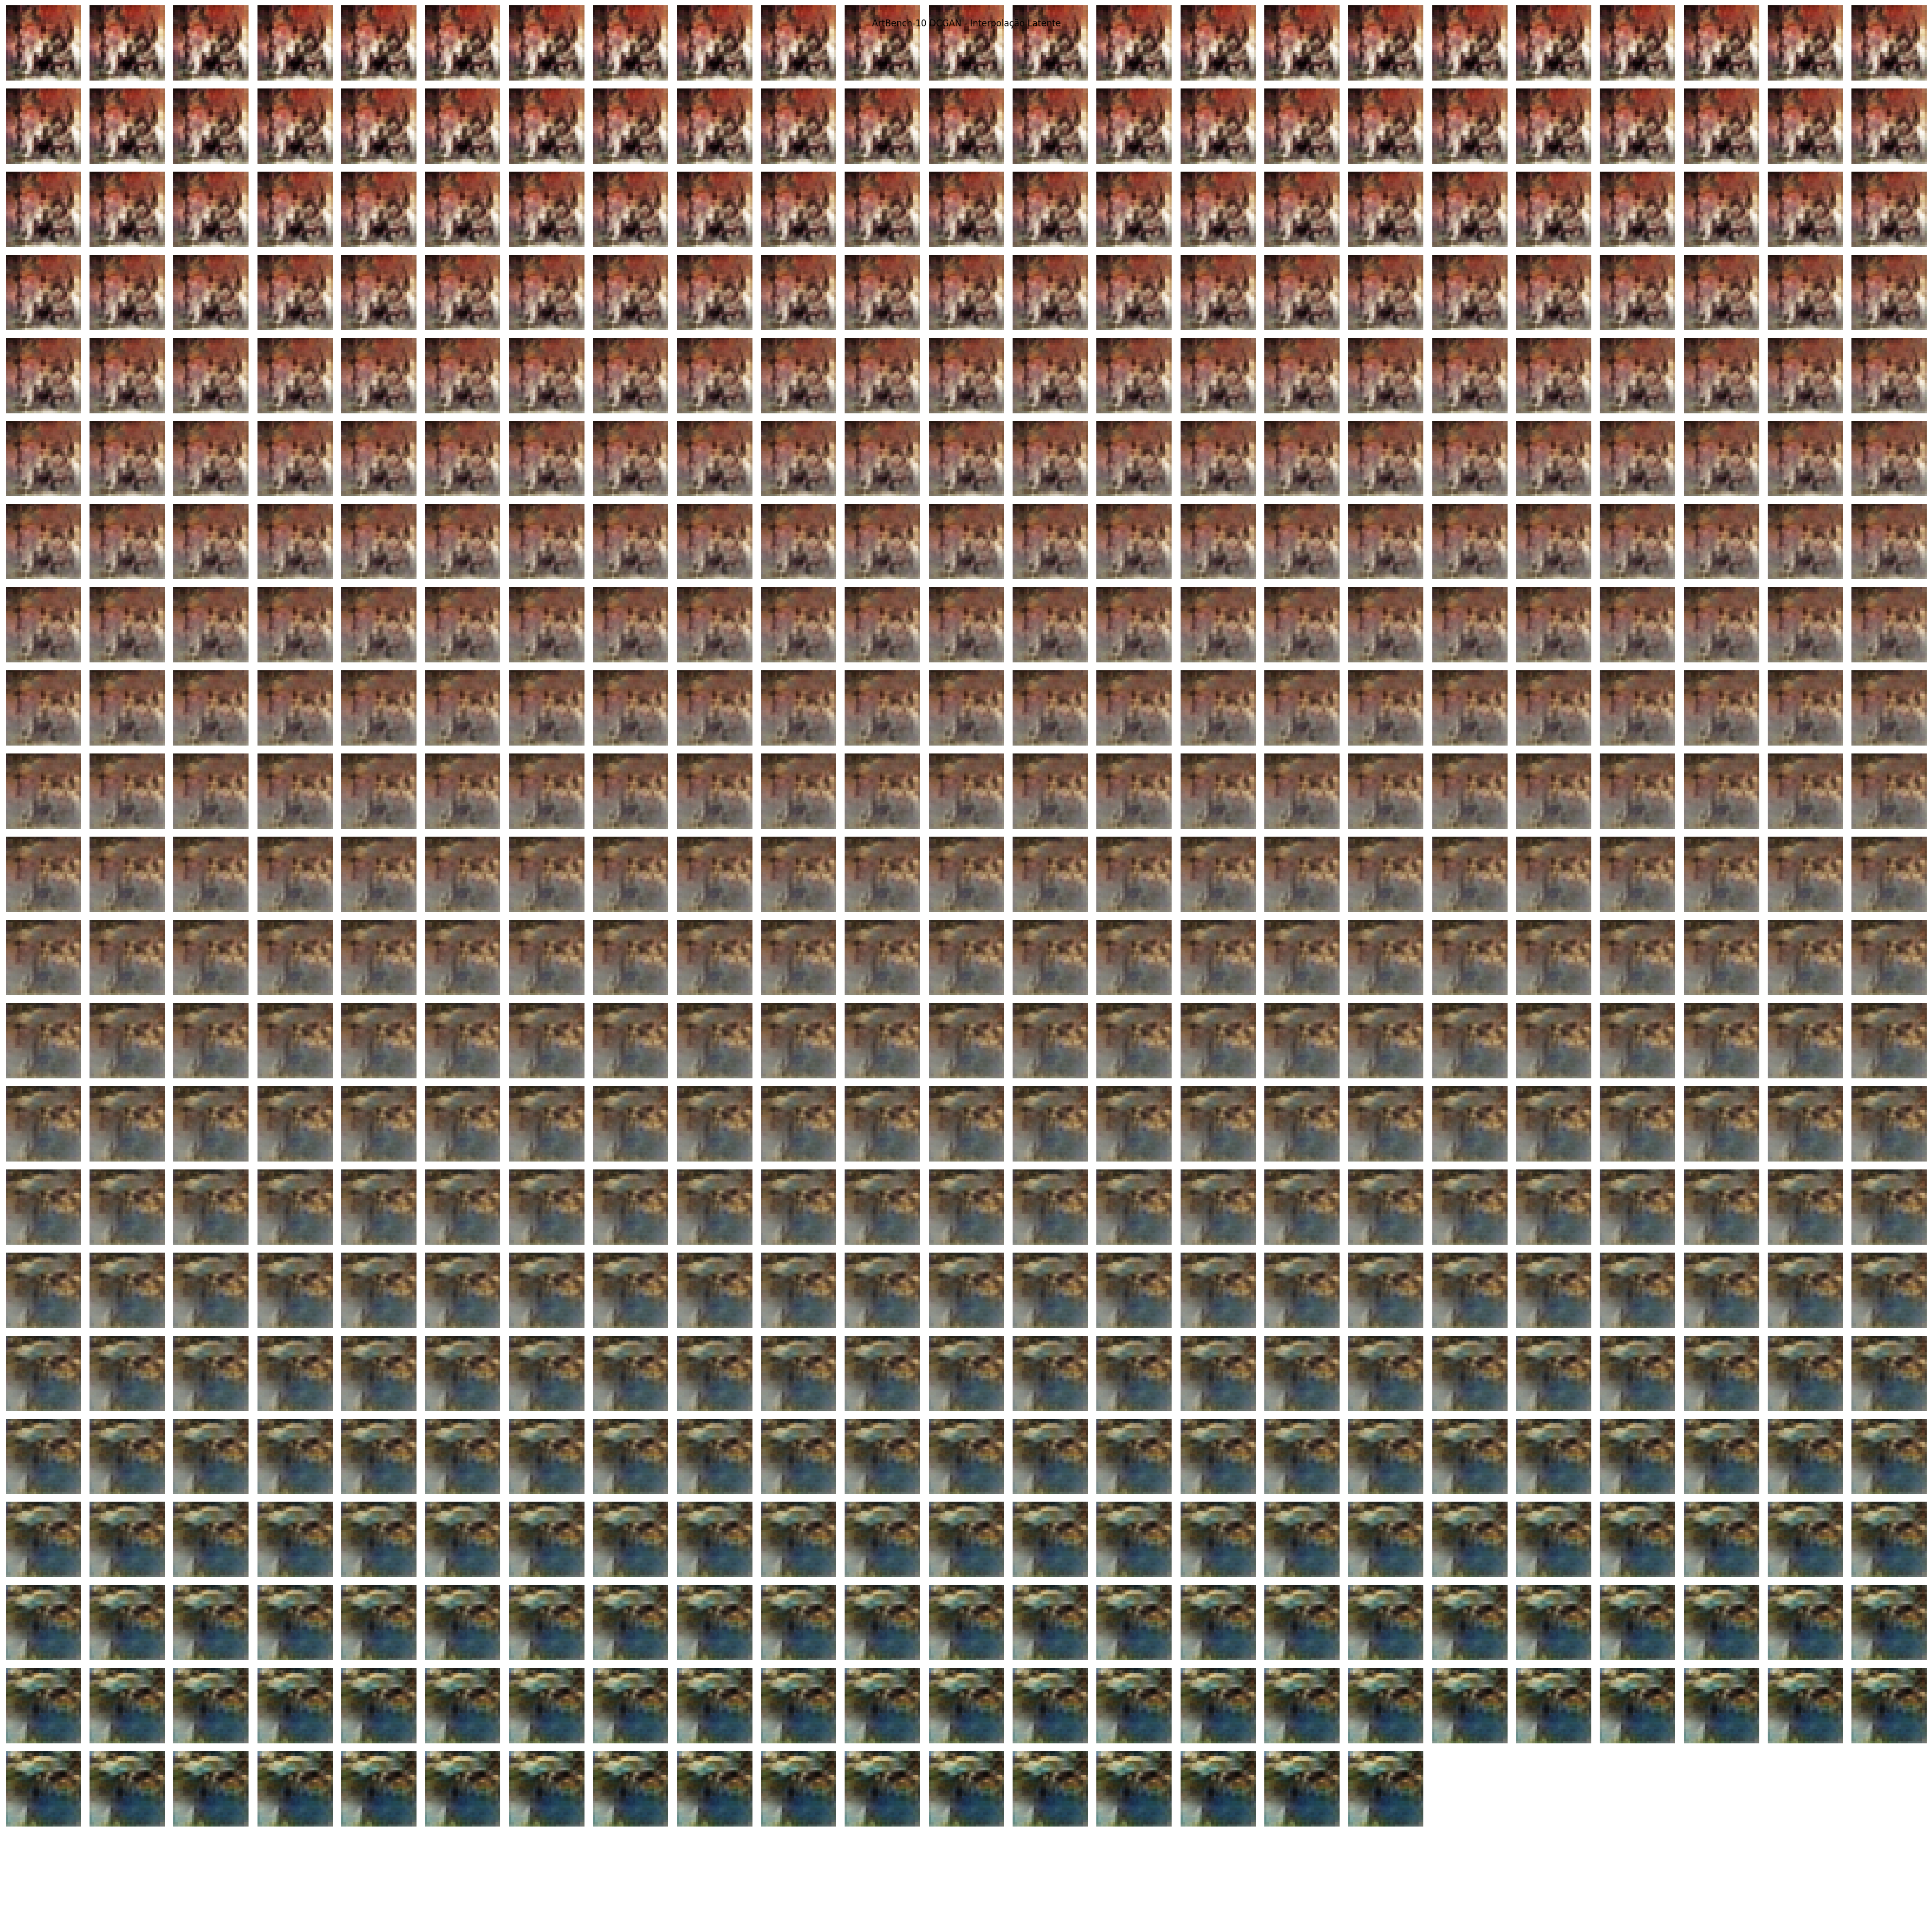

In [16]:
# ==========================================
# 1. CARREGANDO O MODELO TREINADO
# ==========================================
# TODO START
# Usamos a função auxiliar para carregar o Gerador e suas configurações (cfg) do disco
if artbench_ckpt.exists():
    artbench_gen_infer, artbench_cfg, _ = load_dcgan_generator_for_inference(artbench_ckpt)
else:
    print(f"Checkpoint {artbench_ckpt} not found. Skipping inference.")
    artbench_gen_infer = None
    artbench_cfg = None
# TODO END

if artbench_gen_infer is not None and artbench_cfg is not None:
    # ==========================================
    # 2. EXECUTANDO A GERAÇÃO DE IMAGENS
    # ==========================================
    # TODO START
    print("Gerando amostras aleatórias do espaço latente...")
    # Extraímos os valores do dicionário de configuração (cfg) que foi salvo no checkpoint
    run_inference(
        generator=artbench_gen_infer,
        latent_dim=artbench_cfg['latent_dim'],
        channels=artbench_cfg['channels'],
        n_samples=25,
        title='ArtBench-10 DCGAN - Amostras Aleatórias'
    )

    print("\nCaminhando suavemente pelo espaço latente...")
    latent_walk(
        generator=artbench_gen_infer,
        latent_dim=artbench_cfg['latent_dim'],
        channels=artbench_cfg['channels'],
        steps=10, # Vai gerar 10 imagens mostrando a transição de uma obra para outra
        title='ArtBench-10 DCGAN - Interpolação Latente'
    )
    # TODO END